In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [2]:
import torch
from torch.nn import Dropout, Linear, Module, BatchNorm1d
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool

/home/mitsuri/Code/Python/gnn/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Модель

In [3]:
class GCN(Module):
    def __init__(self, dim_in, dim_h):
      super(GCN, self).__init__()

      self.conv1 = GCNConv(dim_in, dim_h)
      self.conv2 = GCNConv(dim_h, dim_h)

      self.bn1 = BatchNorm1d(dim_h)
      self.bn2 = BatchNorm1d(dim_h)

      self.dropout = Dropout(0.25)

      self.linear = Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
      x = self.conv1(x, edge_index)
      x = self.bn1(x)
      x = torch.relu(x)
      x = self.dropout(x)

      x = self.conv2(x, edge_index)
      x = self.bn2(x)
      x = torch.relu(x)

      x = global_mean_pool(x, batch)

      x = self.linear(x)

      return x

### Датасет

In [4]:
from torch._prims_common import DeviceLikeType
from torch_geometric.data import Dataset, Data
from torch_geometric.loader import DataLoader
from sklearn.preprocessing import MinMaxScaler
import torch
import numpy as np
from pandas import DataFrame

StagesDict = dict[str, list[str] | None]

In [5]:
class PolyFilmDataset(Dataset):
    def __init__(
        self,
        df: DataFrame,
        window_size,
        stage_dict: StagesDict,
        step: int = 1,
        limit: int = 0,
        device: DeviceLikeType | None = None
    ):
        super().__init__()
        
        self.df = df.reset_index(drop=True)

        self.stages = stage_dict
        
        self.active_stages = []
        for name, cols in stage_dict.items():
            if cols is not None:
                self.active_stages.append(name)

        self.window_size = window_size

        self.max_features = max(
            len(cols) for cols in stage_dict.values() if cols is not None
        ) * self.window_size

        self.step = step

        # self.df['target'] = (self.df['target'] > limit).astype(int)

        self.window_indices = [
            i for i in range(0, len(self.df) - self.window_size, step)
        ]

        self.device = device

        self.edge_index = self.build_edge_index()

    def len(self) -> int:
        return len(self.window_indices)

    def get(self, idx) -> Data:
        start = self.window_indices[idx]
        end = start + self.window_size

        window = self.df.iloc[start:end]
        target = self.df.iloc[end]['target']

        x = self.window_to_node(window)

        y = torch.tensor([target], dtype=torch.long)

        return Data(x=x, edge_index=self.edge_index, y=y)

    def build_edge_index(self):
        edges = [] 

        for i in range(len(self.active_stages) - 1):
            edges.append([i, i+1])

        if len(edges) == 0:
            return torch.empty((2, 0), dtype=torch.long)

        return torch.tensor(edges, dtype=torch.long).t().contiguous()

    def window_to_node(self, window: DataFrame):
        node_features = []

        for name in self.active_stages:
            cols = self.stages[name]
            
            features = window[cols].values.flatten()

            if len(features) < self.max_features:
                pad = self.max_features - len(features)
                features = np.pad(features, (0, pad))

            node_features.append(features)

        x = torch.tensor(np.vstack(node_features), dtype=torch.float)

        return x

In [6]:
def get_datasets(
    df,
    window_size,
    stage_dict,
    step,
    limit
):
    train_size = int(len(df) * 0.7)
    val_size = int((len(df) - train_size) / 2)

    df['target'] = (df['target'] > limit).astype(int)

    cols = []

    for stage_cols in stage_dict.values():
        if stage_cols is not None:
            cols.extend(stage_cols)

    # print(cols)
    # cols = list(set(cols))
    # print(cols)

    train_data = df.iloc[:train_size]
    eval_data = df.iloc[train_size:train_size + val_size]
    test_data = df.iloc[train_size + val_size:]

    # eval_data = df.iloc[:val_size]
    # test_data = df.iloc[val_size:val_size + val_size]
    # train_data = df.iloc[val_size + val_size:]
  
    # scaler = MinMaxScaler()
    # scaler.fit(df[cols])

    pos = (train_data['target'] == 0).sum()
    neg = (train_data['target'] == 1).sum()

    print('train')
    print(pos)
    print(neg)

    print(pos / pos + neg) 
    print(neg / pos + neg)

    pos_weight = pos / neg

    print('eval')
    pos = (eval_data['target'] == 0).sum()
    neg = (eval_data['target'] == 1).sum()

    print(pos)
    print(neg)
  
    print('test')
    pos = (test_data['target'] == 0).sum()
    neg = (test_data['target'] == 1).sum()

    print(pos)
    print(neg)
  
    # train_data[cols] = scaler.transform(train_data[cols])
    # eval_data[cols] = scaler.transform(eval_data[cols])
    # test_data[cols] = scaler.transform(test_data[cols])

    # print(train_data)

    train_ds = PolyFilmDataset(
        train_data,
        window_size,
        stage_dict,
        step,
        limit
    )

    eval_ds = PolyFilmDataset(
        eval_data,
        window_size,
        stage_dict,
        step,
        limit
    )

    test_ds = PolyFilmDataset(
        test_data,
        window_size,
        stage_dict,
        step,
        limit
    )

    return (train_ds, eval_ds, test_ds, pos_weight)

def get_dataloaders(
    train_ds,
    eval_ds,
    test_ds,
    batch_size
):
    train_dl = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    eval_dl = DataLoader(
        eval_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    test_dl = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
    )

    return (train_dl, eval_dl, test_dl)

### БД

In [7]:
from sqlalchemy import func, select
from sqlalchemy.orm import Session, selectinload
from torch import nn
from db.models import *
import pandas as pd

In [8]:
def get_training_data(
    session: Session,
    defect_id: int,
    parameter_ids: list[int],
    step: int,
    time_from: datetime.datetime,
    time_to: datetime.datetime
):
    all_ids = parameter_ids + [defect_id]

    stmt_params = select(Parameter.IdParameter, Parameter.ParameterCode).where(Parameter.IdParameter.in_(all_ids))

    stmt_stage = (
        select(
            Stage.Name,
            Parameter.ParameterCode
        )
        .join(Parameter, Parameter.IdStage == Stage.IdStage)
        .where(Parameter.IdParameter.in_(parameter_ids))
    )

    stage_rows = session.execute(stmt_stage).all()

    stage_dict = {}

    for stage_name, param_code in stage_rows:
        if stage_name not in stage_dict:
            stage_dict[stage_name] = []

        stage_dict[stage_name].append(param_code)

    param_info = dict(session.execute(stmt_params).all())

    stmt_values = (
        select(
            ParameterValue.IdParameter,
            ParameterValue.DateTime,
            ParameterValue.Value
        )
        .where(ParameterValue.IdParameter.in_(all_ids))
        .where(ParameterValue.DateTime >= time_from)
        .where(ParameterValue.DateTime <= time_to)
        .order_by(ParameterValue.DateTime)
    )

    rows = session.execute(stmt_values).all()

    df = pd.DataFrame(rows, columns=['IdParameter', 'timestamp', 'value'])

    if df.empty:
        return pd.DataFrame()

    df['value'] = pd.to_numeric(df['value'], errors='coerce')

    df = df.drop_duplicates(subset=['timestamp', 'IdParameter'])

    df_pivot = df.pivot(
        index='timestamp',
        columns='IdParameter',
        values='value'
    )

    new_columns = {}

    for param_id in df_pivot.columns:
        if param_id == defect_id:
            new_columns[param_id] = 'target'
        else:
            new_columns[param_id] = param_info.get(param_id, f'param_{param_id}')

    df_pivot.rename(columns=new_columns, inplace=True)

    df_pivot = df_pivot.dropna(how='any')

    df_pivot = df_pivot.iloc[::step]

    df_pivot.reset_index(inplace=True)

    return df_pivot, stage_dict

In [9]:
def get_defect_limit(session: Session, id_defect: int):
    stmt = select(Limit.HighLimitValue).where(Limit.IdParameter == id_defect)

    res = session.execute(stmt).one()

    return res

In [10]:
from sqlalchemy.orm import sessionmaker
from sqlalchemy import create_engine
import datetime as dt

engine = create_engine('sqlite:////home/mitsuri/Code/Python/gnn/extcaland/extcaland.db', echo=False)
sessionmaker = sessionmaker(bind=engine)

### Данные

In [11]:
defect_id = 5 # Количество черных точек
parameter_ids = [1, 2, 3, 29, 31, 33, 34, 36, 37, 39, 40, 42, 43, 49, 50, 52, 53, 55, 56, 58, 59, 61, 63, 64, 66, 67, 69, 70] # параметры всех стадий
step = 1
time_from = dt.datetime.fromisoformat("2020-10-19 11:13:58")
time_to = dt.datetime.fromisoformat("2020-11-06 11:04:19")

window_length = 10
batch_size = 32
epochs = 10
hidden_dim = 64

In [12]:
with sessionmaker() as session:
    df, stage_dict = get_training_data(
      session,
      defect_id,
      parameter_ids,
      step,
      time_from,
      time_to
    )

In [13]:
with sessionmaker() as session:
    limit = get_defect_limit(session, defect_id)

In [14]:
df.describe()

IdParameter,timestamp,OPC_KN_T_ist_Z3_K02,OPC_KN_T_ist_Z1_K02,OPC_KN_T_ist_Z2_K02,target,OPC_V_voronka_K02,OPC_V_shnek_K02,OPC_W1_XT_K02,OPC_W1_XV_K02,OPC_W2_XT_K02,...,OPC_ABZ710_XV_K02,OPC_TW12_XV_K02,OPC_TW13_XT_K02,OPC_TW3_XV_K02,OPC_TW47_XT_K02,OPC_TW47_XV_K02,OPC_TW811_XT_K02,OPC_TW811_XV_K02,OPC_TW1215_XT_K02,OPC_TW1215_XV_K02
count,51637,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,...,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000,51637.000000
mean,2020-10-28 11:10:56.630807,89.018429,50.379881,87.038629,13.632382,6.324819,52.557914,177.110440,11.182790,177.621587,...,15.334381,15.733540,64.235926,15.800639,54.180247,15.803701,47.425182,15.814281,43.027043,15.826900
min,2020-10-19 11:14:31,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,28.800000,0.000000,25.200000,...,0.000000,0.000000,25.500000,0.000000,28.800000,0.000000,32.340000,0.000000,31.640000,0.000000
25%,2020-10-23 23:12:52,26.100000,26.500000,28.400000,4.022000,0.000000,0.000000,180.000000,4.135000,180.000000,...,0.000000,0.000000,27.700000,0.000000,28.800000,0.000000,34.020000,0.000000,33.180000,0.000000
50%,2020-10-28 11:10:19,130.200000,60.700000,126.200000,9.220000,9.337000,78.240000,182.000000,15.220000,183.000000,...,21.205000,21.928000,70.000000,22.004000,65.000000,21.964000,54.880000,21.998000,48.580000,21.996000
75%,2020-11-01 23:09:46,140.600000,65.500000,135.700000,17.719000,12.134000,99.360000,186.000000,17.974000,187.900000,...,30.490000,30.774000,70.000000,30.865000,65.000000,30.916000,56.840000,30.929000,49.980000,30.964000
max,2020-11-06 11:04:19,152.900000,104.600000,147.500000,1076.349000,51.115000,150.000000,207.900000,36.515000,208.500000,...,64.577000,64.860000,130.700000,64.807000,85.100000,65.125000,4776.380000,64.896000,63.840000,64.907000
std,NaN,54.609994,19.464601,51.222768,24.500304,6.275044,51.977947,28.704553,7.546858,29.765399,...,15.271534,15.588159,36.810446,15.646311,21.676576,15.649248,23.703335,15.660188,8.168818,15.673273


In [15]:
stage_dict

{'Подготовка экструдата': ['OPC_KN_T_ist_Z3_K02',
  'OPC_KN_T_ist_Z1_K02',
  'OPC_KN_T_ist_Z2_K02',
  'OPC_V_voronka_K02',
  'OPC_V_shnek_K02'],
 'Каландрование': ['OPC_W1_XT_K02',
  'OPC_W1_XV_K02',
  'OPC_W2_XT_K02',
  'OPC_W2_XV_K02',
  'OPC_W3_XT_K02',
  'OPC_W3_XV_K02',
  'OPC_W4_XT_K02',
  'OPC_W4_XV_K02'],
 'Съём плёнки': ['OPC_ABZ12_XT_K02',
  'OPC_ABZ12_XV_K02',
  'OPC_ABZ36_XT_K02',
  'OPC_ABZ36_XV_K02',
  'OPC_ABZ710_XT_K02',
  'OPC_ABZ710_XV_K02'],
 'Охлаждение плёнки': ['OPC_TW12_XV_K02',
  'OPC_TW13_XT_K02',
  'OPC_TW3_XV_K02',
  'OPC_TW47_XT_K02',
  'OPC_TW47_XV_K02',
  'OPC_TW811_XT_K02',
  'OPC_TW811_XV_K02',
  'OPC_TW1215_XT_K02',
  'OPC_TW1215_XV_K02']}

In [16]:
limit[0]

75.0

In [17]:
(df['target'] > limit).sum()

np.int64(233)

### Обучение

In [18]:
from torch.nn import BCEWithLogitsLoss
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [19]:
import torch
from torch_geometric.loader import DataLoader

def train(
    model: torch.nn.Module,
    loader: DataLoader,
    optimizer,
    criterion,
    device=None
):
    model.train()

    total_loss = 0

    all_preds = []
    all_targets = []
    all_probs = []

    for data in loader:
        data = data.to(device)

        optimizer.zero_grad()

        out = model(data.x, data.edge_index, data.batch).squeeze()

        target = data.y.float().view(-1)

        loss = criterion(out, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * data.num_graphs

        probs = torch.sigmoid(out)
        preds = (probs>0.1).int()

        all_probs.append(probs.detach().cpu())
        all_preds.append(preds.detach().cpu())
        all_targets.append(target.detach().cpu())

    preds = torch.cat(all_preds)
    probs = torch.cat(all_probs)
    targets = torch.cat(all_targets)

    # regression-like metrics
    mae = torch.mean(torch.abs(probs - targets))

    rmse = torch.sqrt(torch.mean((probs - targets) ** 2))

    wape = torch.sum(torch.abs(probs - targets)) / torch.sum(torch.abs(targets) + 1e-8)

    # classification metrics
    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "MAE": mae.item(),
        "RMSE": rmse.item(),
        "WAPE": wape.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
    }

    return metrics


def eval(
    model,
    loader,
    criterion,
    device=None
):
    model.eval()

    total_loss = 0 
    
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch).view(-1)

            target = data.y.float().view(-1)

            loss = criterion(out, target)

            total_loss += loss.item() * data.num_graphs

            probs = torch.sigmoid(out)
            preds = (probs>0.1).int()

            all_probs.append(probs.detach().cpu())
            all_preds.append(preds.detach().cpu())
            all_targets.append(target.detach().cpu())

    preds = torch.cat(all_preds)
    probs = torch.cat(all_probs)
    targets = torch.cat(all_targets)

    # regression-like metrics
    mae = torch.mean(torch.abs(probs - targets))

    rmse = torch.sqrt(torch.mean((probs - targets) ** 2))

    wape = torch.sum(torch.abs(probs - targets)) / torch.sum(torch.abs(targets) + 1e-8)

    # classification metrics
    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    metrics = {
        "loss": total_loss / len(loader.dataset),
        "MAE": mae.item(),
        "RMSE": rmse.item(),
        "WAPE": wape.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
    }

    return metrics


def test(
    model, loader, device=None
):
    all_logits = []
    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for data in loader:
            data = data.to(device)

            out = model(data.x, data.edge_index, data.batch).view(-1)

            target = data.y.float().view(-1)

            probs = torch.sigmoid(out)
            preds = (probs>0.1).int()

            all_logits.append(out.detach().cpu())
            all_probs.append(probs.detach().cpu())
            all_preds.append(preds.detach().cpu())
            all_targets.append(target.detach().cpu())

    logits = torch.cat(all_logits)
    preds = torch.cat(all_preds)
    probs = torch.cat(all_probs)
    targets = torch.cat(all_targets)

    # regression-like metrics
    mae = torch.mean(torch.abs(probs - targets))

    rmse = torch.sqrt(torch.mean((probs - targets) ** 2))

    wape = torch.sum(torch.abs(probs - targets)) / torch.sum(torch.abs(targets) + 1e-8)

    # classification metrics
    tp = ((preds == 1) & (targets == 1)).sum()
    fp = ((preds == 1) & (targets == 0)).sum()
    fn = ((preds == 0) & (targets == 1)).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    metrics = {
        "MAE": mae.item(),
        "RMSE": rmse.item(),
        "WAPE": wape.item(),
        "Precision": precision.item(),
        "Recall": recall.item(),
    }

    return metrics, logits, preds, probs, targets

In [20]:
train_ds, eval_ds, test_ds, pos_weight = get_datasets(
    df,
    window_length,
    stage_dict,
    step,
    limit
)

train
35927
218
219.0
218.00606785982689
eval
7731
15
test
7746
0


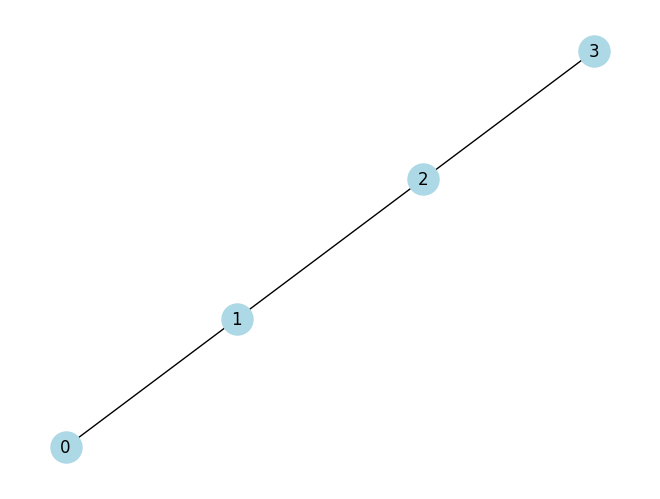

In [46]:
from torch_geometric.utils import to_networkx
import matplotlib.pyplot as plt
import networkx as nx

G = to_networkx(train_ds[0], to_undirected=True)
pos = nx.spring_layout(G)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color='lightblue',
    node_size=500
)
plt.show()

In [45]:
train_dl, eval_dl, test_dl = get_dataloaders(train_ds, eval_ds, test_ds, batch_size=batch_size)

input_dim = train_ds[0].x.shape[1]

In [47]:
input_dim

90

In [24]:
model = GCN(input_dim, hidden_dim)

print(sum(p.numel() for p in model.parameters()))

10305


In [25]:
criterion = BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
optimizer = Adam(model.parameters(), lr=3e-4)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

In [26]:
lrs = []

for epoch in range(1, epochs+1):
    print(epoch)

    train_metrics = train(model, train_dl, optimizer, criterion)
    print('train: ', train_metrics)

    eval_metrics = eval(model, test_dl, criterion)
    print('eval: ', eval_metrics)
    
    scheduler.step(eval_metrics['loss'])

    lrs.append(optimizer.param_groups[0]['lr'])


test_metrics, logits, preds, probs, targets = test(model, eval_dl)
print('test:', test_metrics)

1
train:  {'loss': 1.4782452757368119, 'MAE': 0.3690987825393677, 'RMSE': 0.3742685914039612, 'WAPE': 61.180580139160156, 'Precision': 0.006032932084053755, 'Recall': 1.0}
eval:  {'loss': 0.5467241410139059, 'MAE': 0.42115694284439087, 'RMSE': 0.4211571514606476, 'WAPE': 42115704.0, 'Precision': 0.0, 'Recall': 0.0}
2
train:  {'loss': 1.417500982504589, 'MAE': 0.4411301910877228, 'RMSE': 0.4445337951183319, 'WAPE': 73.1202621459961, 'Precision': 0.006032932084053755, 'Recall': 1.0}
eval:  {'loss': 0.6010167002677917, 'MAE': 0.45174598693847656, 'RMSE': 0.4517459571361542, 'WAPE': 45174612.0, 'Precision': 0.0, 'Recall': 0.0}
3
train:  {'loss': 1.3991238631449316, 'MAE': 0.4727325141429901, 'RMSE': 0.4757992923259735, 'WAPE': 78.35855865478516, 'Precision': 0.006032932084053755, 'Recall': 1.0}
eval:  {'loss': 0.609766960144043, 'MAE': 0.45652249455451965, 'RMSE': 0.4565226137638092, 'WAPE': 45652260.0, 'Precision': 0.0, 'Recall': 0.0}
4
train:  {'loss': 1.4006116316924537, 'MAE': 0.481389

In [27]:
for i in range(20):
    print(
        f"logit={logits[i].item():.3f}, "
        f"prob={probs[i].item():.3f}, "
        f"pred={preds[i].item()}, "
        f"target={targets[i].item()}"
    )

logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0
logit=-0.399, prob=0.402, pred=1, target=0.0


In [28]:
print("mean prob:", probs.mean().item())
print("min prob:", probs.min().item())
print("max prob:", probs.max().item())

mean prob: 0.4016227126121521
min prob: 0.40162262320518494
max prob: 0.40162262320518494


In [29]:
print("targets mean:", targets.float().mean().item())
print("preds mean:", preds.float().mean().item())

targets mean: 0.0019389865919947624
preds mean: 1.0


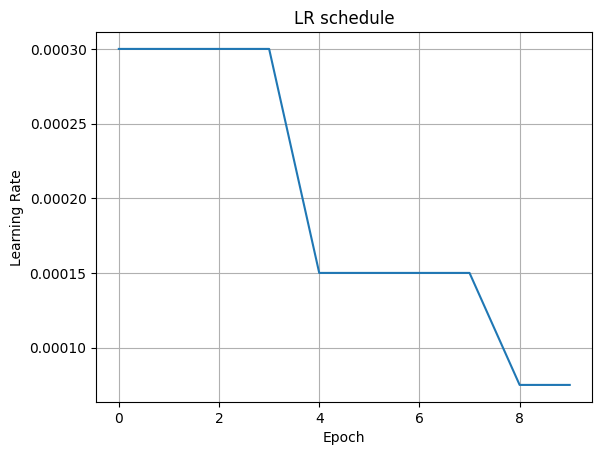

In [30]:
import matplotlib.pyplot as plt

plt.plot(lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("LR schedule")
plt.grid()
plt.show()

### GAT

In [31]:
from torch_geometric.nn import GATConv

In [32]:
class GAT(Module):
    def __init__(self, dim_in, dim_h=64, heads=4, dropout=0.25):
        super(GAT, self).__init__()
  
        self.gat1 = GATConv(
            in_channels=dim_in,
            out_channels=dim_h,
            heads=heads,
        )
        self.gat2 = GATConv(
            in_channels=dim_h * heads,
            out_channels=dim_h,
            heads=1,
        )
  
        self.bn1 = BatchNorm1d(dim_h*heads)
        self.bn2 = BatchNorm1d(dim_h)
  
        self.dropout = Dropout(dropout)
  
        self.linear = Linear(dim_h, 1)

    def forward(self, x, edge_index, batch):
        x = self.gat1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.gat2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = global_mean_pool(x, batch)

        x = self.linear(x)

        return x

In [33]:
# with sessionmaker() as session:
#     df, stage_dict = get_training_data(
#       session,
#       defect_id,
#       parameter_ids,
#       step,
#       time_from,
#       time_to
#     )

In [34]:
# with sessionmaker() as session:
#     limit = get_defect_limit(session, defect_id)

In [35]:
# train_ds, eval_ds, test_ds, pos_weight = get_datasets(
#     df,
#     window_length,
#     stage_dict,
#     step,
#     limit
# )

In [36]:
# print(pos_weight)

In [37]:
# train_dl, eval_dl, test_dl = get_dataloaders(train_ds, eval_ds, test_ds, batch_size=batch_size)

# input_dim = train_ds[0].x.shape[1]

In [38]:
# model = GAT(input_dim, hidden_dim)

# print(sum(p.numel() for p in model.parameters()))

In [39]:
# print(model)

In [40]:
# criterion = BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))
# optimizer = Adam(model.parameters(), lr=3e-4)
# scheduler = ReduceLROnPlateau(
#     optimizer,
#     mode='min',
#     factor=0.5,
#     patience=3,
#     min_lr=1e-6
# )

In [41]:
# for epoch in range(1, epochs+1):
#     print(epoch)

#     train_metrics = train(model, train_dl, optimizer, criterion)
#     print('train: ', train_metrics)

#     eval_metrics = eval(model, test_dl, criterion)
#     print('eval: ', eval_metrics)
    
#     scheduler.step(eval_metrics['loss'])


# test_metrics, logits, preds, probs, targets = test(model, eval_dl)
# print('test:', test_metrics)